## Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import datetime
from datetime import datetime, timedelta

# import matplotlib
from matplotlib import pyplot
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.image as mpimg

# import seaborn
import seaborn as sns

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# to be able to see multiple outputs from single cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

### Import Data

In [3]:
processed_df = pd.read_csv('../../data/processed/final_for_EDA/ttc_cleaned_final_with_peaktimes.csv')
code_description_df = pd.read_csv('../../data/raw/CodeDescriptions.csv')

In [4]:
processed_df.info()
processed_df

code_description_df.info()
code_description_df

<class 'pandas.DataFrame'>
RangeIndex: 20316 entries, 0 to 20315
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   year           20316 non-null  int64
 1   month          20316 non-null  str  
 2   date           20316 non-null  str  
 3   time           20316 non-null  str  
 4   day            20316 non-null  str  
 5   station        20316 non-null  str  
 6   code           20316 non-null  str  
 7   min_delay      20316 non-null  int64
 8   min_gap        20316 non-null  int64
 9   bound          20316 non-null  str  
 10  line           20316 non-null  str  
 11  vehicle        20316 non-null  int64
 12  time_hms       20316 non-null  str  
 13  time_category  20316 non-null  str  
 14  day_category   20316 non-null  str  
dtypes: int64(4), str(11)
memory usage: 2.3 MB


,year,month,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,time_hms,time_category,day_category
0,2025,March,2025-03-16,13:49,Sunday,old mill,PUTIJ,10,14,E,BD,5103,13:49:00,Mid_Day,Weekend
1,2025,January,2025-01-01,2:10,Wednesday,bathurst,MUSAN,5,9,E,BD,5227,02:10:00,Early_AM,Holiday
2,2025,February,2025-02-05,20:38,Wednesday,bathurst,SUDP,5,9,W,BD,5148,20:38:00,Evening,Weekday
3,2025,March,2025-03-21,11:40,Friday,bathurst,MUDD,5,9,W,BD,5170,11:40:00,Mid_Day,Weekday
4,2025,June,2025-06-11,15:32,Wednesday,bathurst,SUO,5,9,E,BD,5035,15:32:00,PM_Peak,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20311,2021,July,2021-07-02,22:20,Friday,yorkdale,SUDP,5,12,N,YU,5691,22:20:00,Late_Evening,Weekday
20312,2021,July,2021-07-27,18:04,Tuesday,yorkdale,TUO,5,8,S,YU,5431,18:04:00,PM_Peak,Weekday
20313,2021,August,2021-08-08,18:23,Sunday,yorkdale,MUO,5,10,S,YU,5856,18:23:00,PM_Peak,Weekend
20314,2026,January,2026-01-25,17:23,Sunday,yorkdale,PUTIS,5,10,N,YU,6056,17:23:00,PM_Peak,Weekend


<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   _id          140 non-null    int64
 1   CODE         140 non-null    str  
 2   DESCRIPTION  140 non-null    str  
dtypes: int64(1), str(2)
memory usage: 3.4 KB


,_id,CODE,DESCRIPTION
0,1,EUAC,AIR CONDITIONING
1,2,EUAL,ALTERNATING CURRENT
2,3,EUATC,ATC RC&S EQUIPMENT
3,4,EUBK,BRAKES
4,5,EUBO,BODY
...,...,...,...
135,136,TUSC,OPERATOR OVERSPEED
136,137,TUSET,CONTROLS IMPROPERLY BLOWN DOWN
137,138,TUST,STORM TRAINS
138,139,TUSUP,SUPERVISORY ERROR


### Review Target Variable

In [5]:
processed_df["code"].value_counts(dropna=True).head(20)

code
SUDP     2739
PUOPO    1460
SUUT     1305
MUIR     1274
SUO      1254
MUI      1032
MUPAA     790
MUSAN     685
MUATC     653
TUO       609
SUAP      537
MUO       453
EUDO      420
SUEAS     402
PUTWZ     396
MUDD      377
TUMVS     272
MUTO      267
EUNT      252
SUG       220
Name: count, dtype: int64

In [6]:
top_codes = processed_df["code"].value_counts().head(20).index
processed_df["code_reduced"] = processed_df["code"].where(
    processed_df["code"].isin(top_codes),
    other="OTHER"
)

### Feature Engineering for Code Prediction

#### Time-Based Features

In [7]:
processed_df["hour"] = pd.to_datetime(processed_df["time_hms"]).dt.hour
processed_df["month_num"] = pd.to_datetime(processed_df["date"]).dt.month

# Cyclical encoding
processed_df["hour_sin"] = np.sin(2*np.pi*processed_df["hour"]/24)
processed_df["hour_cos"] = np.cos(2*np.pi*processed_df["hour"]/24)

#### Location Feature - Frequency Encoding

In [8]:
station_freq = processed_df["station"].value_counts()
processed_df["station_freq"] = processed_df["station"].map(station_freq)

#### Historical Station & Code

To capture how common a code is at a station

In [9]:
station_code_prob = (
    processed_df
    .groupby(["station","code"])
    .size()
    / processed_df.groupby("station").size()
)

processed_df["station_code_likelihood"] = processed_df.set_index(
    ["station","code"]
).index.map(station_code_prob)

#### Delay Severity Category

In [10]:
processed_df["delay_category"] = pd.cut(
    processed_df["min_delay"],
    bins=[0,10,20,50,1000],
    labels=["Low","Medium","High","Extreme"]
)

#### check dataset

In [11]:
processed_df.info()
processed_df

<class 'pandas.DataFrame'>
RangeIndex: 20316 entries, 0 to 20315
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   year                     20316 non-null  int64   
 1   month                    20316 non-null  str     
 2   date                     20316 non-null  str     
 3   time                     20316 non-null  str     
 4   day                      20316 non-null  str     
 5   station                  20316 non-null  str     
 6   code                     20316 non-null  str     
 7   min_delay                20316 non-null  int64   
 8   min_gap                  20316 non-null  int64   
 9   bound                    20316 non-null  str     
 10  line                     20316 non-null  str     
 11  vehicle                  20316 non-null  int64   
 12  time_hms                 20316 non-null  str     
 13  time_category            20316 non-null  str     
 14  day_category     

,year,month,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,time_hms,time_category,day_category,code_reduced,hour,month_num,hour_sin,hour_cos,station_freq,station_code_likelihood,delay_category
0,2025,March,2025-03-16,13:49,Sunday,old mill,PUTIJ,10,14,E,BD,5103,13:49:00,Mid_Day,Weekend,OTHER,13,3,-0.258819,-9.659258e-01,127,0.015748,Low
1,2025,January,2025-01-01,2:10,Wednesday,bathurst,MUSAN,5,9,E,BD,5227,02:10:00,Early_AM,Holiday,MUSAN,2,1,0.500000,8.660254e-01,161,0.037267,Low
2,2025,February,2025-02-05,20:38,Wednesday,bathurst,SUDP,5,9,W,BD,5148,20:38:00,Evening,Weekday,SUDP,20,2,-0.866025,5.000000e-01,161,0.211180,Low
3,2025,March,2025-03-21,11:40,Friday,bathurst,MUDD,5,9,W,BD,5170,11:40:00,Mid_Day,Weekday,MUDD,11,3,0.258819,-9.659258e-01,161,0.080745,Low
4,2025,June,2025-06-11,15:32,Wednesday,bathurst,SUO,5,9,E,BD,5035,15:32:00,PM_Peak,Weekday,SUO,15,6,-0.707107,-7.071068e-01,161,0.105590,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20311,2021,July,2021-07-02,22:20,Friday,yorkdale,SUDP,5,12,N,YU,5691,22:20:00,Late_Evening,Weekday,SUDP,22,7,-0.500000,8.660254e-01,279,0.096774,Low
20312,2021,July,2021-07-27,18:04,Tuesday,yorkdale,TUO,5,8,S,YU,5431,18:04:00,PM_Peak,Weekday,TUO,18,7,-1.000000,-1.836970e-16,279,0.017921,Low
20313,2021,August,2021-08-08,18:23,Sunday,yorkdale,MUO,5,10,S,YU,5856,18:23:00,PM_Peak,Weekend,MUO,18,8,-1.000000,-1.836970e-16,279,0.025090,Low
20314,2026,January,2026-01-25,17:23,Sunday,yorkdale,PUTIS,5,10,N,YU,6056,17:23:00,PM_Peak,Weekend,OTHER,17,1,-0.965926,-2.588190e-01,279,0.007168,Low


#### Selecting:
> * time_category
> * day_category
> * month_num, year
> * hour_sin, hour_cos
> * hour
> * station_freq
> * station_code_likelihood
> * min_gap, min_delay or delay_category
> * bound
> * line

### Target Variable:
> * code_reduced

#### Univariate Statistical Test

For Numerical Features - ANOVA F-Test

In [12]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(processed_df["code_reduced"])

numeric_features = [
    "month_num", "year", "hour",
    "hour_sin", "hour_cos",
    "station_freq", "min_gap", "min_delay",
    "station_code_likelihood"
]

X_num = processed_df[numeric_features]

f_values, p_values = f_classif(X_num, y_encoded)

feature_scores = pd.DataFrame({
    "feature": numeric_features,
    "F_score": f_values,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

feature_scores

,feature,F_score,p_value
8,station_code_likelihood,1366.094658,0.000000e+00
3,hour_sin,127.873642,0.000000e+00
2,hour,70.746454,6.620830e-278
1,year,34.586568,2.939634e-131
5,station_freq,31.735751,1.357958e-119
6,min_gap,29.466023,2.636652e-110
7,min_delay,28.735413,2.573581e-107
4,hour_cos,14.812825,1.207864e-50
0,month_num,5.386301,5.624623e-14


For Categorical Features - Chi-Square Test

In [13]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OrdinalEncoder

cat_features = [
    "time_category",
    "day_category",
    "delay_category",
    "bound",
    "line"
]

X_cat = processed_df[cat_features].astype(str)

encoder = OrdinalEncoder()
X_cat_encoded = encoder.fit_transform(X_cat)

chi_scores, p_vals = chi2(X_cat_encoded, y_encoded)

chi_df = pd.DataFrame({
    "feature": cat_features,
    "chi_score": chi_scores,
    "p_value": p_vals
}).sort_values("chi_score", ascending=False)

chi_df

,feature,chi_score,p_value
4,line,1638.683723,0.000000e+00
0,time_category,1497.205603,1.583725e-305
2,delay_category,94.632593,1.135676e-11
3,bound,32.585826,3.744228e-02
1,day_category,20.334173,4.372078e-01


#### Feature Engineering with Random Forest

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Target
y = processed_df["code_reduced"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Feature selection
features = [
    "time_category",
    "day_category",
    "month_num",
    "year",
    "hour_sin",
    "hour_cos",
    "hour",
    "station_freq",
    "station_code_likelihood",
    "min_gap",
    "min_delay",
    "delay_category",
    "bound",
    "line"
]

X = processed_df[features]


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# Identify categorical columns
categorical_cols = [
    "time_category",
    "day_category",
    "delay_category",
    "bound",
    "line"
]

numeric_cols = list(set(features) - set(categorical_cols))


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# Pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

              precision    recall  f1-score   support

           0       0.09      0.02      0.04        84
           1       0.33      0.08      0.13        50
           2       0.62      0.53      0.57       131
           3       0.32      0.13      0.19        75
           4       0.33      0.32      0.33       207
           5       0.42      0.40      0.41       255
           6       0.37      0.14      0.21        91
           7       0.44      0.51      0.47       158
           8       0.37      0.32      0.34       137
           9       0.48      0.21      0.29        53
          10       0.59      0.94      0.72       984
          11       0.77      0.70      0.73       292
          12       0.73      0.61      0.66        79
          13       0.28      0.15      0.19       108
          14       0.79      0.85      0.82       548
          15       0.37      0.23      0.28        80
          16       1.00      0.50      0.67        44
          17       0.44    

In [15]:
# Get feature names after encoding
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_feature_names = list(encoded_cat_features) + numeric_cols

# Get importances
importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
28,station_code_likelihood,0.234670
21,station_freq,0.133427
23,month_num,0.101437
22,min_gap,0.086012
29,year,0.069403
26,min_delay,0.067205
27,hour,0.053207
24,hour_sin,0.053159
25,hour_cos,0.047202
7,day_category_Weekday,0.017365


<Figure size 1000x800 with 0 Axes>

<BarContainer object of 20 artists>

Text(0.5, 0, 'Feature Importance')

Text(0.5, 1.0, 'Top 20 Random Forest Feature Importances')

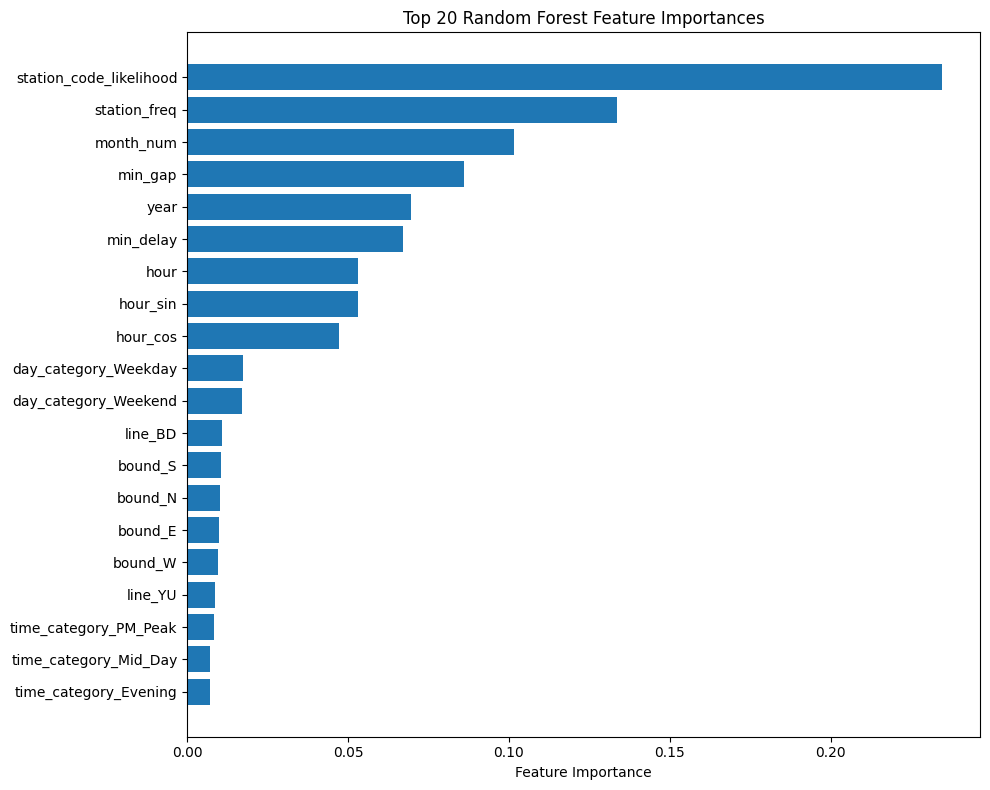

In [16]:
# Sort and take top 20
top_features = importance_df.sort_values(
    "importance", ascending=True
).tail(20)

plt.figure(figsize=(10, 8))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

#### Based on the assessments above, Keep the following features:
> * hour_sin
> * hour
> * year
> * month_num
> * station_freq
> * min_gap
> * line
> * time_category
> * delay_category
> * bound

In [17]:
processed_df.info()
processed_df

<class 'pandas.DataFrame'>
RangeIndex: 20316 entries, 0 to 20315
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   year                     20316 non-null  int64   
 1   month                    20316 non-null  str     
 2   date                     20316 non-null  str     
 3   time                     20316 non-null  str     
 4   day                      20316 non-null  str     
 5   station                  20316 non-null  str     
 6   code                     20316 non-null  str     
 7   min_delay                20316 non-null  int64   
 8   min_gap                  20316 non-null  int64   
 9   bound                    20316 non-null  str     
 10  line                     20316 non-null  str     
 11  vehicle                  20316 non-null  int64   
 12  time_hms                 20316 non-null  str     
 13  time_category            20316 non-null  str     
 14  day_category     

,year,month,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,time_hms,time_category,day_category,code_reduced,hour,month_num,hour_sin,hour_cos,station_freq,station_code_likelihood,delay_category
0,2025,March,2025-03-16,13:49,Sunday,old mill,PUTIJ,10,14,E,BD,5103,13:49:00,Mid_Day,Weekend,OTHER,13,3,-0.258819,-9.659258e-01,127,0.015748,Low
1,2025,January,2025-01-01,2:10,Wednesday,bathurst,MUSAN,5,9,E,BD,5227,02:10:00,Early_AM,Holiday,MUSAN,2,1,0.500000,8.660254e-01,161,0.037267,Low
2,2025,February,2025-02-05,20:38,Wednesday,bathurst,SUDP,5,9,W,BD,5148,20:38:00,Evening,Weekday,SUDP,20,2,-0.866025,5.000000e-01,161,0.211180,Low
3,2025,March,2025-03-21,11:40,Friday,bathurst,MUDD,5,9,W,BD,5170,11:40:00,Mid_Day,Weekday,MUDD,11,3,0.258819,-9.659258e-01,161,0.080745,Low
4,2025,June,2025-06-11,15:32,Wednesday,bathurst,SUO,5,9,E,BD,5035,15:32:00,PM_Peak,Weekday,SUO,15,6,-0.707107,-7.071068e-01,161,0.105590,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20311,2021,July,2021-07-02,22:20,Friday,yorkdale,SUDP,5,12,N,YU,5691,22:20:00,Late_Evening,Weekday,SUDP,22,7,-0.500000,8.660254e-01,279,0.096774,Low
20312,2021,July,2021-07-27,18:04,Tuesday,yorkdale,TUO,5,8,S,YU,5431,18:04:00,PM_Peak,Weekday,TUO,18,7,-1.000000,-1.836970e-16,279,0.017921,Low
20313,2021,August,2021-08-08,18:23,Sunday,yorkdale,MUO,5,10,S,YU,5856,18:23:00,PM_Peak,Weekend,MUO,18,8,-1.000000,-1.836970e-16,279,0.025090,Low
20314,2026,January,2026-01-25,17:23,Sunday,yorkdale,PUTIS,5,10,N,YU,6056,17:23:00,PM_Peak,Weekend,OTHER,17,1,-0.965926,-2.588190e-01,279,0.007168,Low


In [18]:
processed_df.to_csv('../../data/processed/ttc_feature_engineered_final.csv')